# Анализ данных и построение базовых моделей

In [191]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [192]:
plt.style.use('dark_background')
sns.set_theme(style='darkgrid');

In [ ]:
train_data = pd.read_csv("data/train.csv")
test_data = pd.read_csv("data/test.csv")

In [194]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [195]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [196]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [197]:
test_data.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Колонки Age и Cabin имеют пропуски в обоих наборах данных, Embarked имеет 2 пропуска в трейне, а в тесте пропусков нет.  
Напротив, Fare имеет 1 пропуск в тесте, в трейне пропусков нет

Импорты удачные, перейдем к анализу тренировочных данных

## Анализ тренировочных данных

In [198]:
train_data.shape

(891, 12)

In [199]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [200]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [201]:
train_data.describe(include="str")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [202]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Распределение таргета

In [203]:
train_data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [204]:
train_data['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

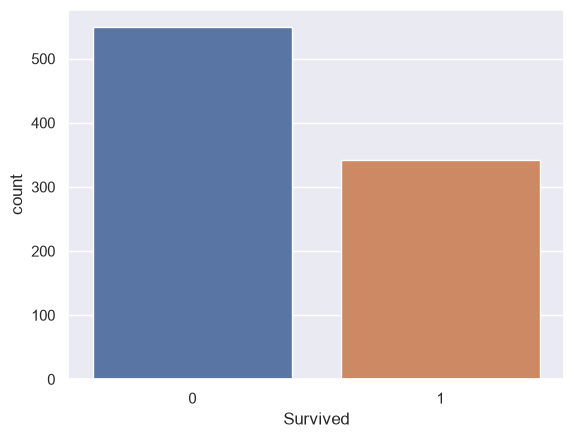

In [205]:
sns.countplot(data=train_data, x='Survived', hue='Survived', legend=False);

### Анализ категориальных фичей

#### Фича Pclass

In [206]:
train_data['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

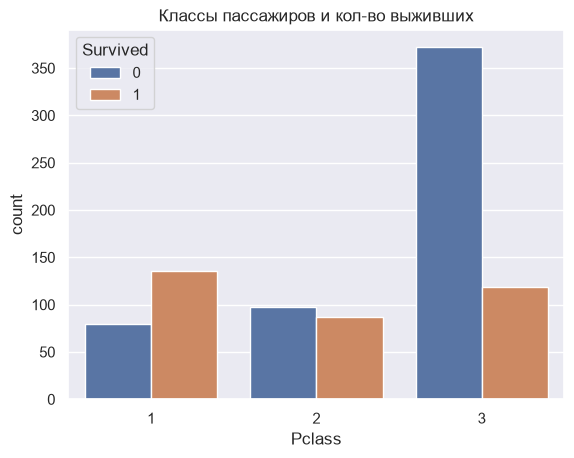

In [207]:
plt.title('Классы пассажиров и кол-во выживших')
sns.countplot(data=train_data, x='Pclass', hue='Survived');

In [208]:
train_data.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

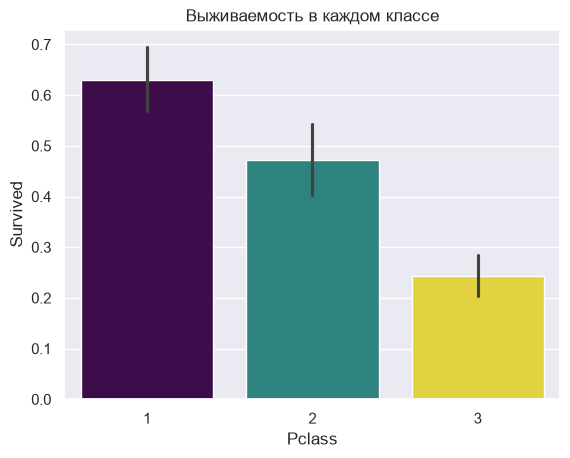

In [209]:
plt.title('Выживаемость в каждом классе')
sns.barplot(data=train_data, x='Pclass', y='Survived', hue='Pclass', palette='viridis', legend=False);

Очевидно, что пассажиры из более хорошего класса выживали с большей вероятностью

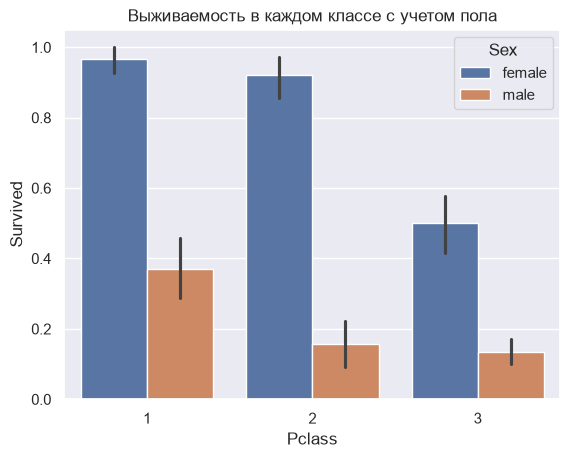

In [210]:
plt.title('Выживаемость в каждом классе c учетом пола')
sns.barplot(data=train_data, x='Pclass', y='Survived', hue='Sex');

Видим, что вне зависимости от класса женщины выживают чаще мужчин

#### Фича Sex

In [211]:
train_data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [212]:
train_data.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Мужчин больше, но выживаемость лучше у женщин

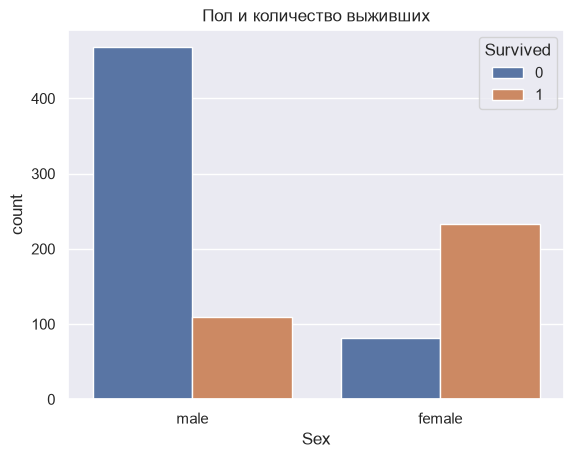

In [213]:
plt.title('Пол и количество выживших')
sns.countplot(data=train_data, x='Sex', hue='Survived');

#### Фича Embarked

In [214]:
train_data['Embarked'].isna().sum()

np.int64(2)

Имеется 2 пропуска в данных

In [215]:
train_data['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

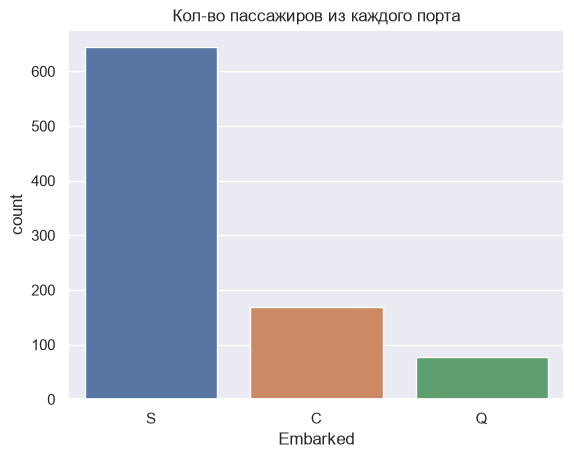

In [216]:
plt.title('Кол-во пассажиров из каждого порта')
sns.countplot(data=train_data, x='Embarked', hue='Embarked', legend=False);

In [217]:
train_data.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

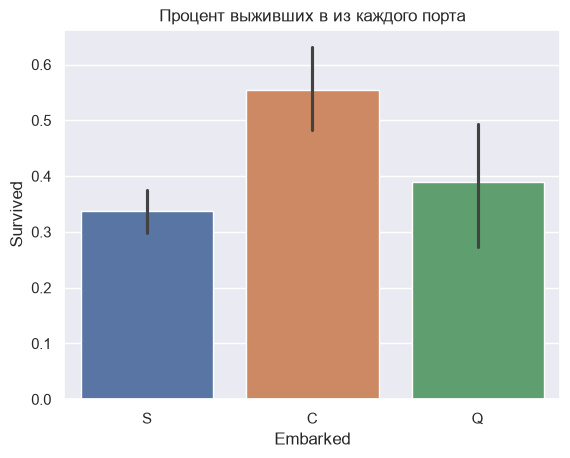

In [218]:
plt.title('Процент выживших в из каждого порта')
sns.barplot(data=train_data, x='Embarked', y='Survived', hue='Embarked', legend=False);

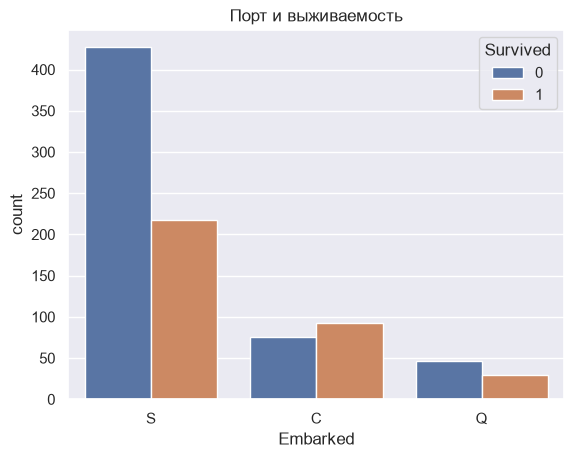

In [219]:
plt.title('Порт и выживаемость')
sns.countplot(data=train_data, x='Embarked', hue='Survived');

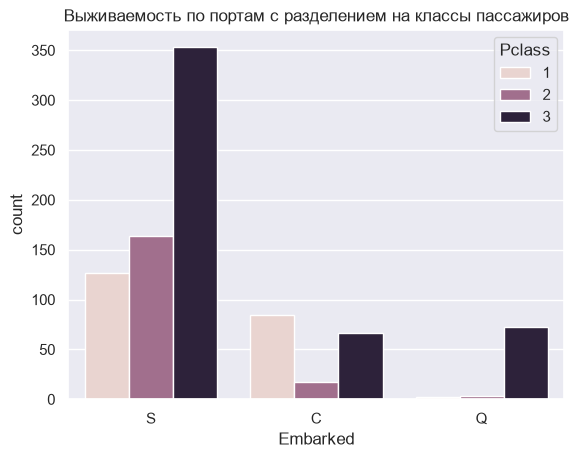

In [220]:
plt.title('Выживаемость по портам с разделением на классы пассажиров')
sns.countplot(data=train_data, x='Embarked', hue='Pclass');

In [221]:
train_data[train_data['Embarked'] == 'Q']['Pclass'].value_counts()

Pclass
3    72
2     3
1     2
Name: count, dtype: int64

Самый многочисленный по пассажирам порт - S, самое большое количесвто людей первого класса из этого порта, однако их доля там меньше относительно других классов  
В порту "C" самая большая доля пассажиров первого класса  
Порт Q самый бичарский и немногочисленный

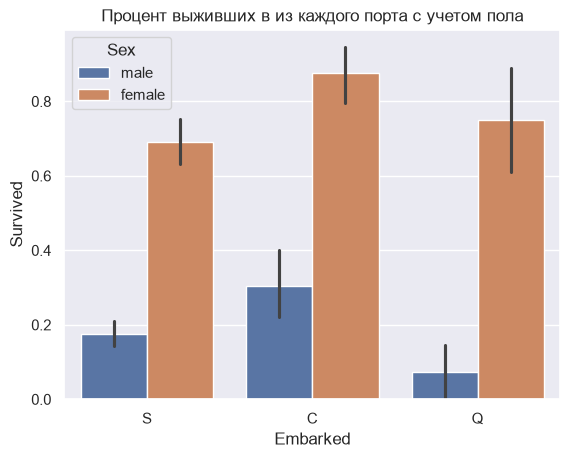

In [222]:
plt.title('Процент выживших в из каждого порта с учетом пола')
sns.barplot(data=train_data, x='Embarked', y='Survived', hue='Sex');

#### Фича SibSp

In [223]:
train_data['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

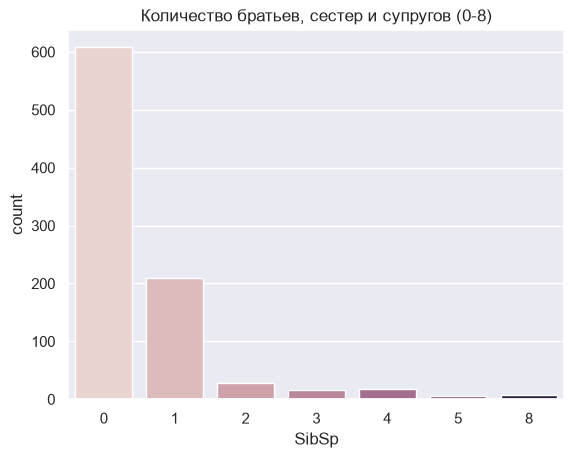

In [224]:
plt.title('Количество братьев, сестер и супругов (0-8)')
sns.countplot(data=train_data, x='SibSp', hue='SibSp', legend=False);

In [225]:
train_data.groupby('SibSp')['Survived'].mean()

SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64

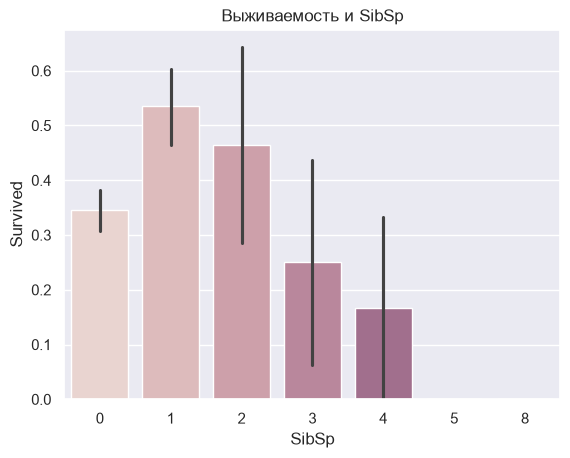

In [226]:
plt.title('Выживаемость и SibSp')
sns.barplot(data=train_data, x='SibSp', y='Survived', hue='SibSp', legend=False);

In [227]:
table = pd.crosstab(
    [train_data['Pclass'], train_data['SibSp']],
    train_data['Survived'],
    margins=True
)
table.style.background_gradient(cmap='viridis')


Количество SibSp большее чем 3 встречается только в 3-ем классе, да и SibSp==2 или SibSp==3 в 1-ом и 2-ом классе единичные случаи

Иметь 1 или 2 SibSp в среднем выгоднее, чем 0, однако большее количество SibSp ведет к снижению шансов на выживание, плюс это пересекается с классом

#### Фича Parch

In [228]:
train_data['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

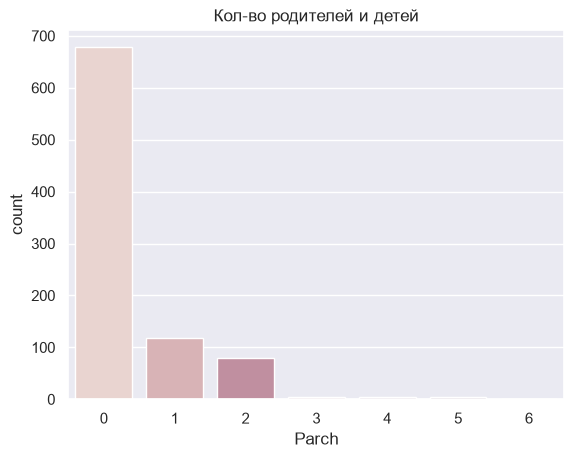

In [229]:
plt.title('Кол-во родителей и детей')
sns.countplot(data=train_data, x='Parch', hue='Parch', legend=False);

Значения 3-6 встречаются крайне редко 

In [230]:
train_data.groupby('Parch')['Survived'].mean()

Parch
0    0.343658
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64

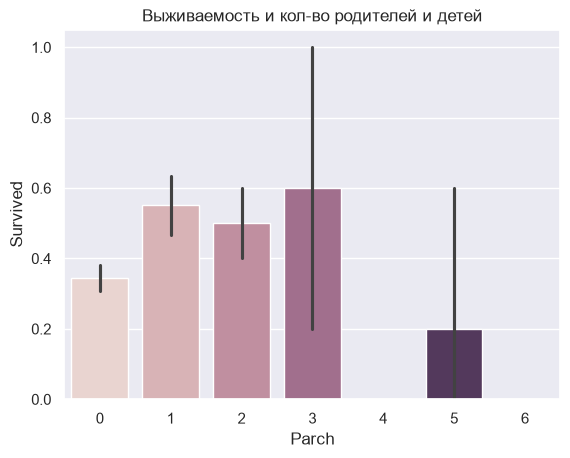

In [231]:
plt.title('Выживаемость и кол-во родителей и детей')
sns.barplot(data=train_data, x='Parch', y='Survived', hue='Parch', legend=False);

Группы 3-6 малочисленны, поэтому нельзя воспринимать выживаемость для них как нечто значимое